In [94]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [95]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import mode, zscore
from scipy.signal import savgol_filter, find_peaks
from neurodsp.aperiodic import compute_irasa, fit_irasa
from collections import defaultdict

# Functions

##### Get list of files

In [96]:
def get_files(dir_path, search_term):
    """
    Get a list of all files in directory containing specific search term.

    Parameters:
        dir_path (str): path to dir with all files.
        search_term (str): specific term needed in .mat file name.

    Returns:
        files (list): List with all files containing the search term.
    """
    files = []

    # iterate files in dir
    for file in os.listdir(dir_path):
        # check if search term in file name
        if search_term in file:
            files.append(file)

    return files


##### Load eeg data

In [97]:
def load_eeg(eeg_path, search_term):
    """
    Load EEG data in .mat format.

    Parameters:
        path (str): Path to EEG .mat file.
        search_term (str): specific term needed in .mat file.
    
    Returns:
        eeg_data (array): 1d array containing EEG data.
    """
    # load .mat eeg file 
    eeg_data = loadmat(os.path.join(main_path, eeg_path))
    # retrieve array from file
    eeg_data = next(v for k, v in eeg_data.items() if search_term in k)
    # create 1d array
    eeg_data = np.squeeze(eeg_data)

    return eeg_data

##### Load states data

In [98]:
def load_states(state_path, epoch, sf):
    """
    Load states data in .mat format and downscale to epoch size.

    Parameters:
        state_path (str): path to states .mat file.
        epoch (int): Epoch length in seconds.
        sf (int): Sampling frequency.

    Returns:
        state_data (array): 1d array containing sleep state data.
    """
    # load .mat state file
    state_data = loadmat(os.path.join(main_path, state_path))
    # retrieve state data from file
    state_data = state_data['states'].flatten()
    # set datatype to int
    state_data = np.array(state_data, dtype=int)
    # downscale the state to epoch size
    state_data = state_data[:len(state_data) // (epoch*sf) * (epoch*sf)].reshape(-1, epoch*sf)
    # ensure its a 1d array
    state_data = mode(state_data, axis=1).mode.flatten()

    return state_data

##### Convert raw eeg data into epochs

In [99]:
def raw_to_epochs(eeg_data, sf, epoch):
    """
    Convert raw data arary to epoch sized array.

    Parameters:
        eeg_data (array): 1d array containing EEG data.
        sf (int): Sampling frequency.
        epoch (int): Epoch length in seconds.
    
    Returns:
        epochs (array): 2d array of EEG data in epochs.
    """
    # total amount of samples per epoch
    samples_per_epoch = int(epoch * sf)
    # number of epochs in data
    n_epochs = len(eeg_data) // samples_per_epoch
    # cut data to full epochs
    cropped_data = eeg_data[:n_epochs * samples_per_epoch]
    # reshape to epochs
    epochs = cropped_data.reshape(n_epochs, samples_per_epoch)
    print("New data shape:", epochs.shape)

    return epochs

##### Calculate fractal component

In [100]:
def calc_fractal_component(sleep_states, epoched_data, fs, f_range):
    """
    Calculate fractal component of the EEG data using neurodsp irasa function.

    Parameters:
        sleep_states (array): Array containing the sleep states.
        epoched_data (2d array): 2d array containing all epoched data.
        fs (int): Sampling frequency.
        f_range (tuple): Frequency range to calculate PSD in e.g. (0.3, 30).
    
    Returns: 
        irasa_mean_by_state (dict): Dictionary with aperiodic mean per sleep state.
    """
    irasa_by_state = defaultdict(list)

    # calculate aperiodic for all epochs per state
    for eeg_epoch, state in zip(epoched_data, sleep_states):
        freqs, psd_aperiodic, _ = compute_irasa(eeg_epoch, fs, f_range=f_range)
        irasa_by_state[state].append([freqs, psd_aperiodic])

    irasa_mean_by_state = {}

    # calculate aperiodic mean per state
    for state, irasa_list in irasa_by_state.items():
        aperiodics = np.array([ap for _, ap in irasa_list])
        freqs = irasa_list[0][0]
        mean_aperiodic = np.mean(aperiodics, axis=0)
        irasa_mean_by_state[state] = (freqs, mean_aperiodic)

    # remove index 5, which corresponds to movement/artefacts
    if 5 in irasa_mean_by_state:
        del irasa_mean_by_state[5]

    return irasa_mean_by_state

##### Calculate slopes

In [101]:
def calc_slopes(epoched_data, fs, f_range, states):
    """
    Calculate aperiodic slope using the neurodsp irasa function. 
    Calculate z-score and calculate means.

    Parameters:
        epoched_data (2d array): 2d array containing all epoched data.
        fs (int): Sampling frequency.
        f_range (tuple): Frequency range to calculate PSD in e.g. (0.3, 30).
        states (array): 1d array with sleep states.

    Returns:
        raw_slopes (list): list of z computed slopes.
        smoothed_slopes (list): list of smoothed z computed slopes.
        mean_slope_per_state (dict): Mean slope per state.
        smoothed_mean_slope_per_state (dict): Smoothed mean slope per state.
    """
    epoch_slopes = []

    # calculate slope
    for epoch in epoched_data:
        freqs, psd_aperiodic, _ = compute_irasa(epoch, fs, f_range=f_range)
        intercept, slope = fit_irasa(freqs, psd_aperiodic)
        epoch_slopes.append(slope)

    # calculate z-score    
    raw_slopes = zscore(epoch_slopes)
    smoothed_slopes = savgol_filter(raw_slopes, 101, polyorder=5)
    smoothed_slopes = zscore(smoothed_slopes)

    # lists for the raw and smoothed means
    mean_slope_per_state = {}
    smoothed_mean_slope_per_state = {}

    # get mean slopes
    for state in np.unique(states):
        mask = states == state
        mean_slope_per_state[state] = np.mean(raw_slopes[mask])
        smoothed_mean_slope_per_state[state] = np.mean(smoothed_slopes[mask])

    return raw_slopes, smoothed_slopes, mean_slope_per_state, smoothed_mean_slope_per_state

## Variables

In [102]:
# static variables
epoch = 30
fmin = 0.3
fmax = 30
f_range = (0.3, 30)

## Paths

In [103]:
# main paths
# edf_path = r"D:\dilon_data\mat_collection\test\fpz"
# sleep_states_path = r"D:\dilon_data\mat_collection\test\states"
main_path = r"D:\dilon_data\mat_collection\static"

# test files
# eeg_dataset = [r"S35_1\S35_1_E214_Delta_Sigma_Beta.mat", r"S36_2\S36_2_E59_Theta_Sigma_Beta.mat"]
# states_dataset = [r'S35_1\S35_1_states.mat', r'S36_2\S36_2_states.mat']

# Main

### EEG time series

##### Get file paths

In [104]:
# get all file paths
# eeg_dataset = get_files(edf_path, "Fpz-Cz")
# states_dataset = get_files(sleep_states_path, "states")
eeg_dataset = get_files(main_path, "Fpz-Cz")
states_dataset = get_files(main_path, "states")
# check to see how many files 
print(f"There are {len(eeg_dataset)} files available in the EEG directory")
print(f"There are {len(states_dataset)} files available in the EEG directory")

There are 311 files available in the EEG directory
There are 311 files available in the EEG directory


##### Load data per subject

In [105]:
subject_fractal_data = {}
subject_slope_data = {}
subject_states = {}

# iterate file paths per subject
for eeg_path, states_path in zip(eeg_dataset, states_dataset):
    # isolate search term
    search_term = eeg_path.split("_")[2].split(".")[0]
    # get subject name
    subject = "_".join(eeg_path.split('_')[:2])
    if "SC" in subject or "ST" in subject:
        sf = 100
    else:
        sf = 250
    # prepare eeg
    eeg = load_eeg(eeg_path, search_term)
    # prepare states
    states = load_states(states_path, epoch, sf)
    subject_states[subject] = states

    # get eeg data in epochs
    eeg_in_epochs = raw_to_epochs(eeg, sf, epoch)

    # calculate fractal component
    subject_fractal_data[subject] = calc_fractal_component(states, eeg_in_epochs, sf, f_range)

    try:
        # calculate slopes
        subject_slope_data[subject] = calc_slopes(eeg_in_epochs, sf, f_range, states)
    except:
        continue



New data shape: (1029, 7500)
New data shape: (972, 7500)
New data shape: (923, 7500)
New data shape: (1011, 7500)
New data shape: (1035, 7500)
New data shape: (1029, 7500)
New data shape: (1075, 7500)
New data shape: (1001, 7500)
New data shape: (1048, 7500)
New data shape: (1138, 7500)
New data shape: (1051, 7500)
New data shape: (1066, 7500)
New data shape: (1019, 7500)
New data shape: (1004, 7500)
New data shape: (1109, 7500)
New data shape: (1095, 7500)
New data shape: (1092, 7500)
New data shape: (1056, 7500)
New data shape: (1066, 7500)
New data shape: (861, 7500)
New data shape: (970, 7500)
New data shape: (964, 7500)
New data shape: (1016, 7500)
New data shape: (958, 7500)
New data shape: (979, 7500)
New data shape: (1108, 7500)
New data shape: (1207, 7500)
New data shape: (1059, 7500)
New data shape: (1027, 7500)
New data shape: (969, 7500)
New data shape: (1017, 7500)
New data shape: (1019, 7500)
New data shape: (1025, 7500)
New data shape: (1018, 7500)
New data shape: (976, 

c:\Users\andri\miniconda3\envs\rodent_model\Lib\site-packages\neurodsp\aperiodic\irasa.py:140: RuntimeWarning: divide by zero encountered in log10
  popt, _ = curve_fit(fit_func, np.log10(freqs), np.log10(psd_aperiodic))


New data shape: (1092, 3000)


c:\Users\andri\miniconda3\envs\rodent_model\Lib\site-packages\neurodsp\aperiodic\irasa.py:140: RuntimeWarning: divide by zero encountered in log10
  popt, _ = curve_fit(fit_func, np.log10(freqs), np.log10(psd_aperiodic))


New data shape: (1208, 3000)
New data shape: (1166, 3000)
New data shape: (984, 3000)
New data shape: (1024, 3000)
New data shape: (1188, 3000)
New data shape: (2162, 3000)
New data shape: (2027, 3000)
New data shape: (1910, 3000)
New data shape: (1101, 3000)
New data shape: (1041, 3000)
New data shape: (1326, 3000)
New data shape: (1103, 3000)
New data shape: (1087, 3000)
New data shape: (954, 3000)
New data shape: (997, 3000)
New data shape: (1096, 3000)
New data shape: (1056, 3000)
New data shape: (1717, 3000)
New data shape: (1148, 3000)
New data shape: (1047, 3000)


...

c:\Users\andri\miniconda3\envs\rodent_model\Lib\site-packages\neurodsp\aperiodic\irasa.py:140: RuntimeWarning: divide by zero encountered in log10
  popt, _ = curve_fit(fit_func, np.log10(freqs), np.log10(psd_aperiodic))


New data shape: (1324, 3000)


c:\Users\andri\miniconda3\envs\rodent_model\Lib\site-packages\neurodsp\aperiodic\irasa.py:140: RuntimeWarning: divide by zero encountered in log10
  popt, _ = curve_fit(fit_func, np.log10(freqs), np.log10(psd_aperiodic))


New data shape: (1241, 3000)
New data shape: (1229, 3000)
New data shape: (1293, 3000)
New data shape: (1185, 3000)
New data shape: (1705, 3000)
New data shape: (1366, 3000)
New data shape: (1092, 3000)
New data shape: (1040, 3000)
New data shape: (920, 3000)
New data shape: (944, 3000)
New data shape: (1008, 3000)
New data shape: (1126, 3000)


KeyboardInterrupt: 

In [113]:
import pickle

# Save to file
with open("subject_fractal_data.pkl", "wb") as f:
    pickle.dump(subject_fractal_data, f)

# Save to file
with open("subject_slope_data.pkl", "wb") as f:
    pickle.dump(subject_slope_data, f)


### Get averages for the fractal component and slopes

In [114]:
### fractal components
aperiodic_by_state = defaultdict(list)
freqs_ref = {}

for subject, subject_dict in subject_fractal_data.items():
    for state, (freqs, aperiodic) in subject_dict.items():
        aperiodic_by_state[state].append(aperiodic)
        freqs_ref[state] = freqs

mean_by_state = {}
sem_by_state = {}

for state, aperiodic_list in aperiodic_by_state.items():
    arr = np.stack(aperiodic_list, axis=0)
    mean_by_state[state] = (freqs_ref[state], np.mean(arr, axis=0))
    sem_by_state[state] = (freqs_ref[state], np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]))


### slopes
raw_slope_by_state = defaultdict(list)
smoothed_slope_by_state = defaultdict(list)

for subject, (_, _, raw_slopes, smoothed_slopes) in subject_slope_data.items():
    for state, slope in raw_slopes.items():
        raw_slope_by_state[state].append(slope)
    for state, slope in smoothed_slopes.items():
        smoothed_slope_by_state[state].append(slope)

mean_raw_slope_by_state = {}
sem_raw_slope_by_state = {}
mean_smoothed_slope_by_state = {}
sem_smoothed_slope_by_state = {}

for state, slope_list in raw_slope_by_state.items():
    slope_array = np.vstack(slope_list)
    mean_raw_slope_by_state[state] = np.mean(slope_array, axis=0)
    sem_raw_slope_by_state[state] = np.std(slope_array, axis=0) / np.sqrt(slope_array.shape[0])

for state, slope_list in smoothed_slope_by_state.items():
    slope_array = np.vstack(slope_list)
    mean_smoothed_slope_by_state[state] = np.mean(slope_array, axis=0)
    sem_smoothed_slope_by_state[state] = np.std(slope_array, axis=0) / np.sqrt(slope_array.shape[0])

# Visualize the fractal power component in log log space

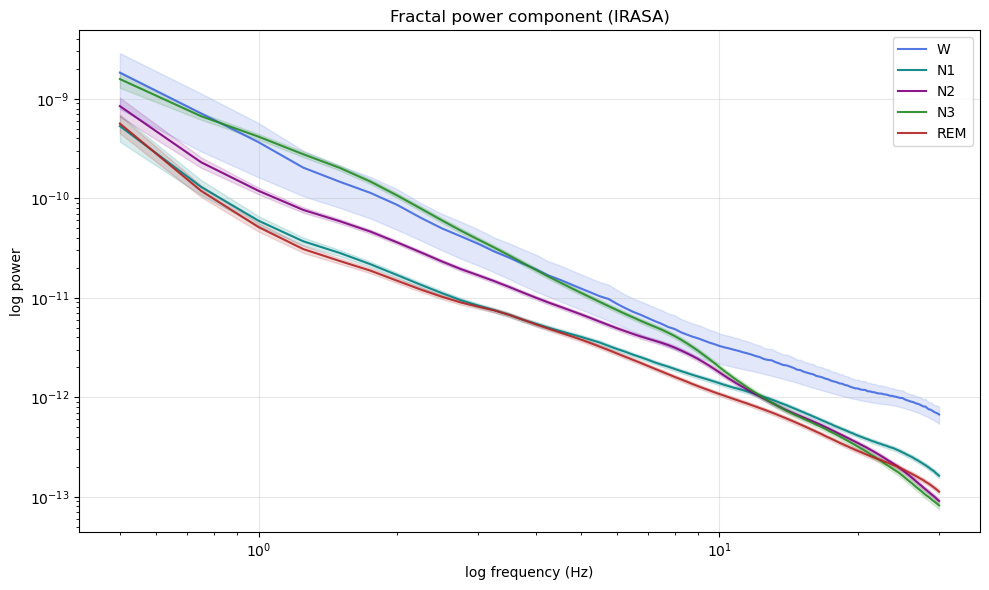

In [119]:
# Colors and labels
colors = {0: 'royalblue', 1: 'teal', 2: 'purple', 3: 'forestgreen', 4: 'firebrick'}
stage_labels = {0: 'W', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

# initialize plot
plt.figure(figsize=(10, 6))

# plot for each sleep state
for state in [0,1,2,3,4]:
    freqs, mean_aperiodic = mean_by_state[state]
    _, sem_aperiodic = sem_by_state[state]

    # average values
    plt.plot(
        freqs, mean_aperiodic,
        label=stage_labels.get(state, f"State {state}"),
        alpha=0.9,
        color=colors.get(state, 'gray')
    )
    
    # Shaded SEM area chatGPT prompt: How to shade plot line with SEM values
    plt.fill_between(
        freqs,
        mean_aperiodic - sem_aperiodic,
        mean_aperiodic + sem_aperiodic,
        color=colors.get(state, 'gray'),
        alpha=0.15
    )

# plot formatting and appearance
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log frequency (Hz)')
plt.ylabel('log power')
plt.title('Fractal power component (IRASA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# f_range = (0.3, 30)
# epoch_slopes = []

# for eeg_epoch in eeg_in_epochs:
#     freqs, psd_aperiodic, _ = compute_irasa(eeg_epoch, sf, f_range=f_range)
#     intercept, slope = fit_irasa(freqs, psd_aperiodic)
#     epoch_slopes.append(slope)
# raw_slopes = zscore(epoch_slopes)
# smoothed_slopes = savgol_filter(raw_slopes, 101, polyorder=5)
# smoothed_slopes = zscore(smoothed_slopes)

# mean_slope_per_state = {}
# smoothed_mean_slope_per_state = {}

# # Extract mean slopes in a consistent order
# for state in np.unique(states):
#     mask = states == state
#     mean_slope_per_state[state] = np.mean(raw_slopes[mask])
#     smoothed_mean_slope_per_state[state] = np.mean(smoothed_slopes[mask])

# stages_sorted = sorted(mean_slope_per_state.keys())
# mean_slopes = [mean_slope_per_state[s] for s in stages_sorted]
# smoothed_mean_slopes = [smoothed_mean_slope_per_state[s] for s in stages_sorted]

# Visualize the average slope per sleep stage

[0, 1, 2, 3, 4]


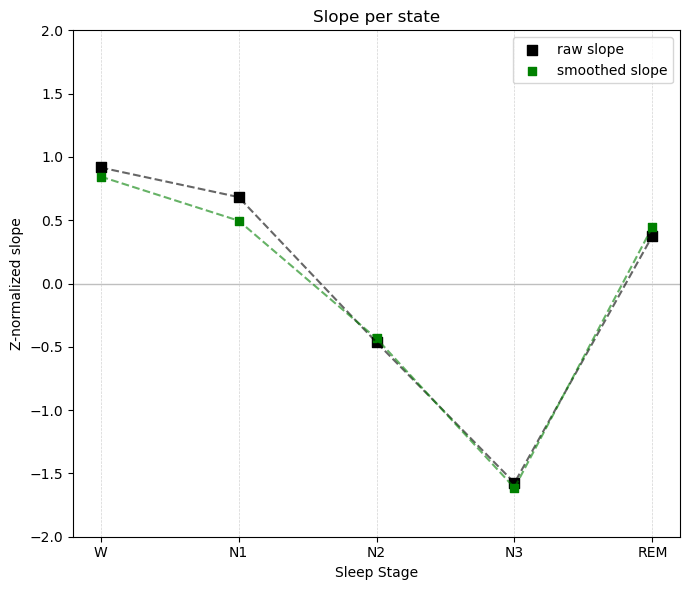

In [116]:
#stages_sorted = sorted(mean_raw_slope_by_state.keys())
stages_sorted = [0,1,2,3,4]
print(stages_sorted)

# extract means per state
mean_slopes = [np.mean(mean_raw_slope_by_state[state]) for state in stages_sorted if state in mean_raw_slope_by_state]
smoothed_mean_slopes = [np.mean(mean_smoothed_slope_by_state[state]) for state in stages_sorted if state in mean_smoothed_slope_by_state]

# initialize plot
plt.figure(figsize=(7, 6))

# draw grid in the background
plt.grid(axis='x', color='lightgray', linestyle='--', linewidth=0.5, zorder=0)
plt.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)

# create datapoints in plot
plt.scatter(stages_sorted, mean_slopes, color='black', marker='s', s=60, label='raw slope', zorder=2)
plt.scatter(stages_sorted, smoothed_mean_slopes, color='green', marker='s', s=30, label='smoothed slope', zorder=2)
plt.plot(stages_sorted, mean_slopes, color='black', linestyle='--', alpha=0.6, zorder=2)
plt.plot(stages_sorted, smoothed_mean_slopes, color='green', linestyle='--', alpha=0.6, zorder=2)

# plot formatting and appearance
plt.xticks(stages_sorted, ['W','N1','N2','N3','REM'])
plt.ylabel('Z-normalized slope')
plt.xlabel('Sleep Stage')
plt.title('Slope per state')
plt.ylim(-2, 2)
plt.legend()
plt.tight_layout()
plt.show()



# Averaged slopes per sleep state

# Visualization of fractal cycles vs classical cycles

### Select subject to visualize

In [118]:
print(len(list(subject_slope_data.keys())))

203


In [117]:
print("Here is a list of all subjects:")
for subject, temp in subject_slope_data.items():
    print(subject)

Here is a list of all subjects:
S40_2
S35_1
S35_2
S41_1
S41_2
S90_2
S42_1
S42_2
S36_1
S36_2
S89_2
S43_1
S43_2
S91_1
S91_2
S78_1
S78_2
S44_1
S44_2
S92_1
S92_2
S37_1
S37_2
S77_1
S77_2
S93_1
S38_1
S38_2
S79_1
S79_2
S94_1
S94_2
S39_1
S39_2
S71_1
S71_2
S95_1
S95_2
S93_2
S80_1
S80_2
S96_1
S96_2
S60_1
S60_2
S97_1
S97_2
S81_1
S81_2
S98_1
S98_2
S72_1
S72_2
SC400_1
SC400_2
SC401_1
SC401_2
SC402_1
SC402_2
SC403_1
SC403_2
SC404_1
SC404_2
SC405_1
SC405_2
SC406_1
SC406_2
SC407_1
SC407_2
SC408_1
SC408_2
SC409_1
SC409_2
SC410_1
SC410_2
SC411_1
SC411_2
SC412_1
SC412_2
SC413_1
SC414_1
SC414_2
SC415_1
SC415_2
SC416_1
SC416_2
SC417_1
SC417_2
SC418_1
SC418_2
SC419_1
SC419_2
SC420_1
SC420_2
SC421_1
SC421_2
SC422_1
SC422_2
SC423_1
SC423_2
SC424_1
SC424_2
SC425_1
SC425_2
SC426_1
SC426_2
SC427_1
SC427_2
SC428_1
SC428_2
SC429_1
SC429_2
SC430_1
SC430_2
SC431_1
SC431_2
SC432_1
SC432_2
SC433_1
SC433_2
SC434_1
SC434_2
SC435_1
SC435_2
SC436_2
SC437_1
SC437_2
SC438_1
SC438_2
SC440_1
SC440_2
SC441_1
SC441_2
SC442_1
SC

In [124]:
# choose a subject from the above list to visualize the fractal cycles
subject = "S36_1"

_, smoothed_slopes, _, _ = subject_slope_data.get(subject)
subj_states = subject_states.get(subject)

### The actual visualization

In [125]:
### ChatGPT promt: How to find peaks and valleys in data
peaks, _ = find_peaks(smoothed_slopes, distance=40, prominence=0.9, height=0)

### chatGPT promt: annotate the last wake index before sleep and the 
### first wake index after sleep as peaks
# Find the last wake before sleep in metadata for additional peaks
# # First non-Wake peak
# first_non_wake_idx = np.where(subj_states != 0)[0][0]
# if first_non_wake_idx not in peaks:
#     peaks = np.insert(peaks, 0, first_non_wake_idx)
# fubd the first wake after sleep in metadata
# # Last non-Wake peak
# last_non_wake_idx = np.where(subj_states != 0)[0][-1]
# if last_non_wake_idx not in peaks:
#     peaks = np.append(peaks, last_non_wake_idx)

valleys, _ = find_peaks(-smoothed_slopes, distance=40, prominence=0.9)

In [126]:
print(len(subj_states))

1048


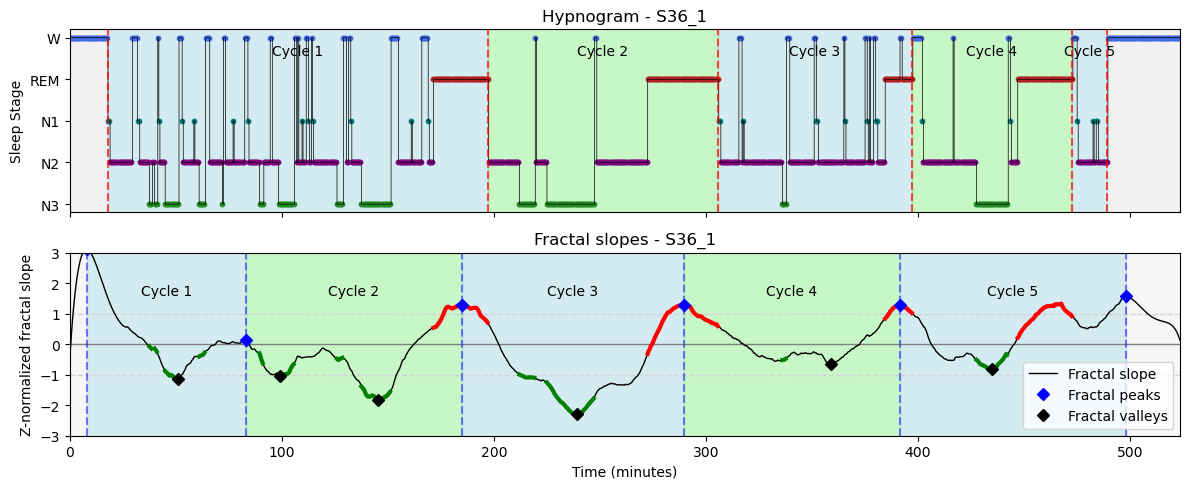

In [127]:
### Most of this function was generated using chatGPT. From displayed 
### the peaks and valleys to drawing automatic lines at each peak to 
### automatically separate the plot into the fractal peaks.
### Automatically drawing lines in the hypnogram based on last rem 
### sleep, with the ability to skip gaps and more

import pandas as pd

# epoch_length_sec = 30  # adjust for dataset
n_epochs = len(subj_states)
time_axis = np.arange(n_epochs) * epoch / 60  # minutes

# define sleep stage colors
# Replace 5 with 0
subj_states[subj_states == 5] = 0
subj_states[subj_states == 6] = 0

# define labels and colors to use
stage_colors = {0: 'royalblue', 1: 'teal', 2: 'purple', 3: 'forestgreen', 4: 'firebrick'}
stage_labels = {0: 'W', 1:'N1', 2:'N2', 3: 'N3', 4: 'REM'}

# parameters for rem line drawing
REM_code = 4
min_rem_gap = 20  # ignore interruptions <= 1 epoch

# first non wake and last non wake
non_wake_idx = np.where(subj_states != 0)[0]
first_non_wake = non_wake_idx[0] if len(non_wake_idx) > 0 else None
last_non_wake = non_wake_idx[-1] if len(non_wake_idx) > 0 else None

# find rem clusters
is_rem = (subj_states == REM_code).astype(int)
diff = np.diff(np.concatenate(([0], is_rem, [0])))
run_starts = np.where(diff == 1)[0]
run_ends = np.where(diff == -1)[0] - 1

# merge short interruptions 
merged_starts = [run_starts[0]] if len(run_starts) > 0 else []
merged_ends = []
for i in range(1, len(run_starts)):
    if run_starts[i] - run_ends[i-1] - 1 <= min_rem_gap:
        continue
    else:
        merged_ends.append(run_ends[i-1])
        merged_starts.append(run_starts[i])
if len(run_ends) > 0:
    merged_ends.append(run_ends[-1])



# Desired order for y-axis
desired_order = ['W', 'REM', 'N1', 'N2', 'N3']

# Map original numeric states to their labels
stage_labels = {0:'W', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}

# Create a mapping: original numeric code -> new vertical position
new_y_map = {label: i for i, label in enumerate(desired_order)}
states_labels = np.array([stage_labels[s] for s in subj_states])
states_new_y = np.array([new_y_map[s] for s in states_labels])

# create plot layout (2 plots in 1 figure)
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,5), sharex=True)


### plot 1: colored coded hypnogram
#######################################################################
# plot plain black line hypnogram
# --- Create list of vertical line positions ---
line_positions = [first_non_wake] + merged_ends if first_non_wake is not None else merged_ends
# Add the last non-wake if it isn’t already in the list
if last_non_wake is not None and last_non_wake not in line_positions:
    line_positions.append(last_non_wake)
line_positions = [0] + line_positions + [len(subj_states)-1]  # include start and end
line_times = time_axis[line_positions]

# --- Plot hypnogram ---
ax1.step(time_axis, states_new_y, where='post', color='black', linewidth=0.5, zorder=2)

# Shade regions between lines (alternating) and outside
colors = ['lightgreen', 'lightblue']
for i in range(1, len(line_times)-2):
    start = line_times[i]
    end = line_times[i+1]
    ax1.axvspan(line_times[i], line_times[i+1], color=colors[i % 2], alpha=0.5, zorder=1)
    # Add cycle label at the center of the shaded region
    center = (start + end) / 2
    ax1.text(center, 0.5, f'Cycle {i}',
             ha='center', va='bottom', fontsize=10, color='black')

# Shade outside areas
ax1.axvspan(time_axis[0], line_times[1], color='lightgray', alpha=0.3, zorder=0)     # before first non-Wake/cluster
ax1.axvspan(line_times[-2], time_axis[-1], color='lightgray', alpha=0.3, zorder=0)   # after last cluster

# Draw vertical lines
for t in line_times[1:-1]:  # avoid start and end
    ax1.axvline(t, color='red', linestyle='--', alpha=0.7, zorder=3)

# plot dots colored based on state
for s_num in np.unique(subj_states):
    ids = np.where(subj_states == s_num)[0]
    ax1.scatter(time_axis[ids], states_new_y[ids],
                color=stage_colors[s_num], label=stage_labels[s_num], s=10)

# additional settings
ax1.set_yticks(range(len(desired_order)))
ax1.set_yticklabels(desired_order)
ax1.set_ylabel('Sleep Stage')
ax1.invert_yaxis()
ax1.set_xlim(time_axis[0], time_axis[-1])
ax1.set_title(f'Hypnogram - {subject}')


### plot 2: smoothed fractal slope
########################################################################
ax2.plot(time_axis, smoothed_slopes, color='black', label='Fractal slope', linewidth=1)
# color lines based on sleep state
# Define colors for N3 and REM
stage_colors = {3: 'green', 4: 'red'}

# Loop over stages to color the segments
for stage, color in stage_colors.items():
    # Find contiguous segments of this stage
    mask = (subj_states == stage)
    if not np.any(mask):
        continue  # skip if stage not present
    
    # Split into contiguous segments
    segments = np.split(time_axis, np.where(np.diff(mask.astype(int)) != 0)[0]+1)
    slope_segments = np.split(smoothed_slopes, np.where(np.diff(mask.astype(int)) != 0)[0]+1)
    
    for t_seg, s_seg, m_seg in zip(segments, slope_segments, np.split(mask, np.where(np.diff(mask.astype(int)) != 0)[0]+1)):
        if np.any(m_seg):  # only plot segments where mask is True
            ax2.plot(t_seg[m_seg], s_seg[m_seg], color=color, linewidth=3)

# plot the peaks and valleys
ax2.plot(time_axis[peaks], smoothed_slopes[peaks], 'D', color='blue', label='Fractal peaks')
for peak in peaks:
    ax2.axvline(time_axis[peak], color='blue', linestyle='--', alpha=0.5)
# Shade regions between consecutive peaks, alternating white and light gray
colors = ['lightblue', 'lightgreen']
for i in range(len(peaks)-1):
    start = time_axis[peaks[i]]
    end = time_axis[peaks[i+1]]
    ax2.axvspan(start, end, color=colors[i % 2], alpha=0.5)
    # Add cycle label at the center of the shaded region
    center = (start + end) / 2
    ax2.text(center, 1.5, f'Cycle {i+1}',
             ha='center', va='bottom', fontsize=10, color='black')

# Shade outside areas with light blue
ax2.axvspan(time_axis[0], time_axis[peaks[0]], color='lightgray', alpha=0.2)          # before first peak
ax2.axvspan(time_axis[peaks[-1]], time_axis[-1], color='lightgray', alpha=0.2) 

ax2.plot(time_axis[valleys], smoothed_slopes[valleys], 'D', color='black', label='Fractal valleys')  # mark dips

# Solid line at 0
ax2.axhline(0, color='gray', linewidth=1, zorder=1)

# Dashed lines at +1 and -1
ax2.axhline(1, color='lightgray', linestyle='--', linewidth=1, zorder=1)
ax2.axhline(-1, color='lightgray', linestyle='--', linewidth=1, zorder=1)

# additional settings
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Z-normalized fractal slope')
ax2.set_ylim(-3, 3)
ax2.set_xlim(time_axis[0], time_axis[-1])
ax2.set_title(f'Fractal slopes - {subject}')
ax2.legend()
plt.tight_layout()
plt.show()